# Phase 4: Linear Regression Regularization (Ridge & Lasso)
This notebook trains linear models, applies feature scaling, and implements L1/L2 regularization to compare against our tree ensembles.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### 1. Load splits, feature engineer, and isolate variables

In [2]:
train_df = pd.read_csv("../artifacts/train.csv")
test_df = pd.read_csv("../artifacts/test.csv")

for df in [train_df, test_df]:
    df['Pavement_Age'] = 2026 - df['Beläggningsår']

features = ['Spårdjup max 15', 'ÅDT fordon', 'Pavement_Age', 'Hastighetsgräns', 'Spårdjup max 17', 'Vägbredd']
X_train_raw = train_df[features]
y_train = train_df['IRI höger']
X_test_raw = test_df[features]
y_actual = test_df['IRI höger']

### 2. Standardize Features (Crucial for Regularized Linear Models)

In [3]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

os.makedirs("../artifacts", exist_ok=True)
with open("../artifacts/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("StandardScaler initialized, transformed, and saved successfully.")

StandardScaler initialized, transformed, and saved successfully.


### 3. Loop Train and Score Linear Algorithms

Linear_Regression_Vanilla  | R²:  28.1% | MAE: 0.942 | RMSE: 1.333
Ridge_Regression_L2        | R²:  28.1% | MAE: 0.942 | RMSE: 1.333
Lasso_Regression_L1        | R²:  28.1% | MAE: 0.940 | RMSE: 1.333


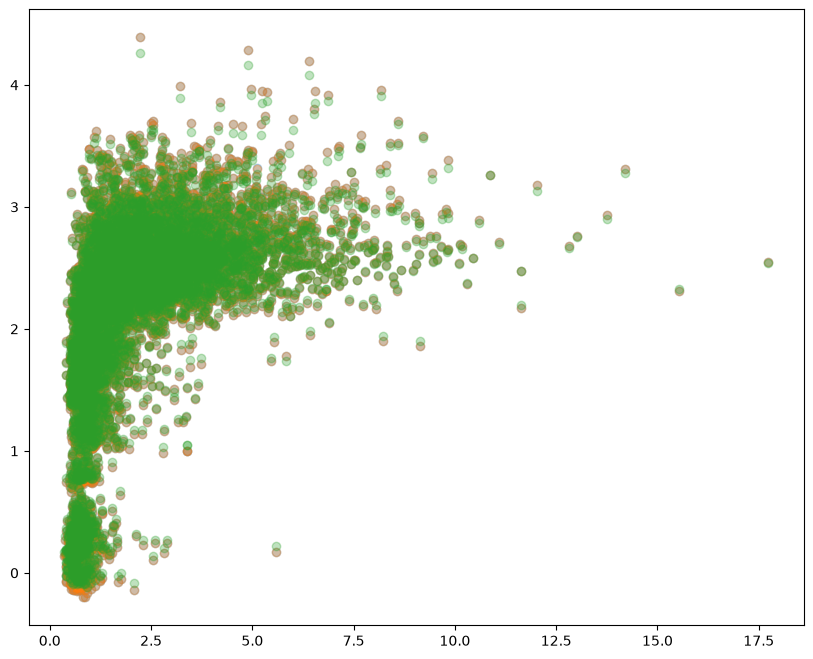

In [4]:
linear_models = {
    "Linear_Regression_Vanilla": LinearRegression(),
    "Ridge_Regression_L2": Ridge(alpha=1.0),
    "Lasso_Regression_L1": Lasso(alpha=0.01)
}

linear_report = {}
plt.figure(figsize=(10, 8))

for name, model in linear_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_actual, y_pred)
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    
    linear_report[name] = {"r2": r2, "model": model}
    print(f"{name:26} | R²: {r2*100:5.1f}% | MAE: {mae:.3f} | RMSE: {rmse:.3f}")
    
    plt.scatter(y_actual, y_pred, alpha=0.3, label=f'{name} (R²: {r2*100:.1f}%)')
    
    with open(f"../artifacts/model_{name}.pkl", "wb") as f:
        pickle.dump(model, f)

### 4. Plot Comparison Visualization Layout

In [ ]:
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.title('Linear Models Evaluation: Actual vs Predicted IRI')
plt.xlabel('Actual IRI')
plt.ylabel('Predicted IRI')
plt.legend()
plt.grid(True)
plt.show()